In [1]:
!pip install qiskit

In [2]:
!pip install flwr

In [3]:
!pip install scikit-learn

In [4]:
!pip install matplotlib

In [5]:
!pip install shap

In [6]:
!pip install numpy

In [7]:
!pip install pandas

In [8]:
#QKD Simulation (BB84 Protocol)
import numpy as np

def simulate_bb84(n_bits=100):
    alice_bits = np.random.randint(2, size=n_bits)
    alice_bases = np.random.randint(2, size=n_bits)
    bob_bases = np.random.randint(2, size=n_bits)

    # Simulate transmission
    bob_results = []
    for i in range(n_bits):
        if alice_bases[i] == bob_bases[i]:
            bob_results.append(alice_bits[i])
        else:
            bob_results.append(np.random.randint(2))

    bob_results = np.array(bob_results)

    # Key sifting
    matching = alice_bases == bob_bases
    sifted_alice = alice_bits[matching]
    sifted_bob = bob_results[matching]

    # QBER calculation
    errors = np.sum(sifted_alice != sifted_bob)
    qber = errors / len(sifted_alice) if len(sifted_alice) > 0 else 0

    return qber, len(sifted_alice)

In [9]:
#Dataset Generation
import pandas as pd

def generate_dataset(samples=500):
    data = []

    for _ in range(samples):
        qber, key_len = simulate_bb84()

        # Simulate attack
        attack = np.random.choice([0, 1])

        if attack == 1:
            qber += np.random.uniform(0.1, 0.3)

        noise = np.random.uniform(0, 0.1)

        data.append([qber, key_len, noise, attack])

    df = pd.DataFrame(data, columns=["qber", "key_length", "noise", "label"])
    return df

df = generate_dataset(1000)
print(df.head())

       qber  key_length     noise  label
0  0.000000          48  0.045023      0
1  0.260122          60  0.041800      1
2  0.168061          50  0.041580      1
3  0.135971          48  0.014718      1
4  0.271021          57  0.089867      1


In [10]:
#Machine Learning Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00       104

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



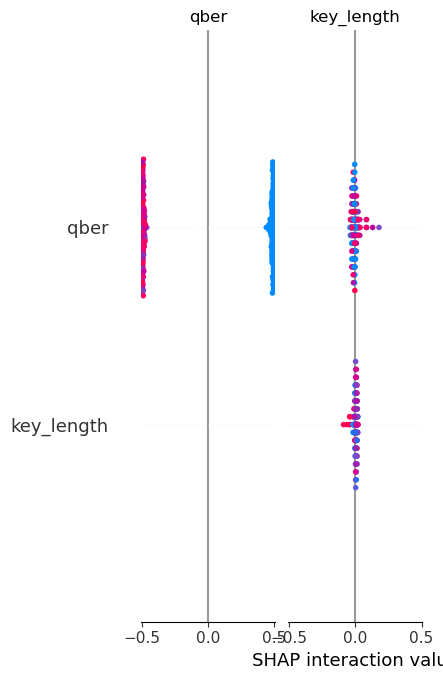

In [11]:
#Explainable AI (SHAP)
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [12]:
#Adversial Robustness
def add_adversarial_noise(X):
    noise = np.random.normal(0, 0.05, X.shape)
    return X + noise

X_adv = add_adversarial_noise(X_test)
y_pred_adv = model.predict(X_adv)

print("Adversarial Performance:")
print(classification_report(y_test, y_pred_adv))

Adversarial Performance:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        96
           1       0.89      1.00      0.94       104

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200



In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model.fit(X_scaled, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


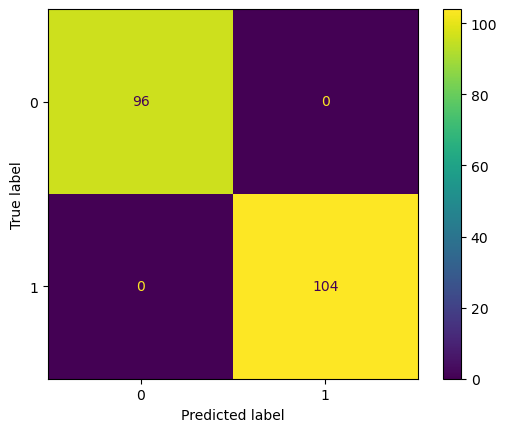

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [15]:
#Federated Learning
def federated_training(data, num_clients=3):
    client_models = []

    split_data = np.array_split(data, num_clients)

    for client_data in split_data:
        X = client_data.drop("label", axis=1)
        y = client_data["label"]

        model = RandomForestClassifier()
        model.fit(X, y)
        client_models.append(model)

    return client_models

In [16]:
# In real FL → weights aggregation
# Here → ensemble voting

def federated_predict(models, X):
    preds = np.array([m.predict(X) for m in models])
    return np.round(np.mean(preds, axis=0))

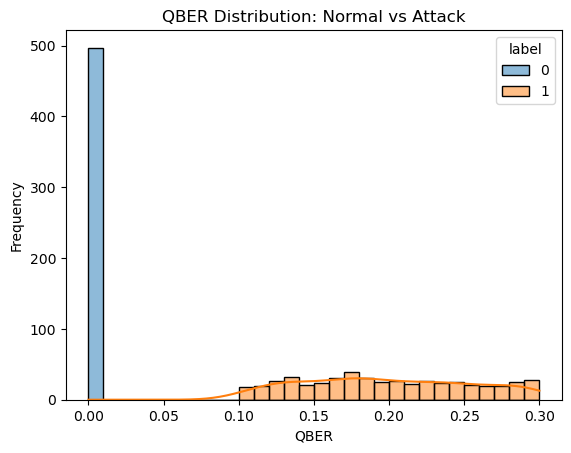

In [17]:
#QBER Distribution (Normal vs Attack)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="qber", hue="label", bins=30, kde=True)
plt.title("QBER Distribution: Normal vs Attack")
plt.xlabel("QBER")
plt.ylabel("Frequency")
plt.show()

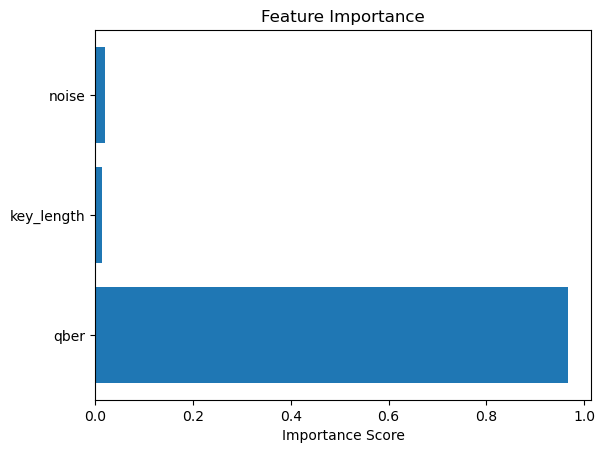

In [18]:
#Feature Importance Visualization
import pandas as pd

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

(200, 3, 2)


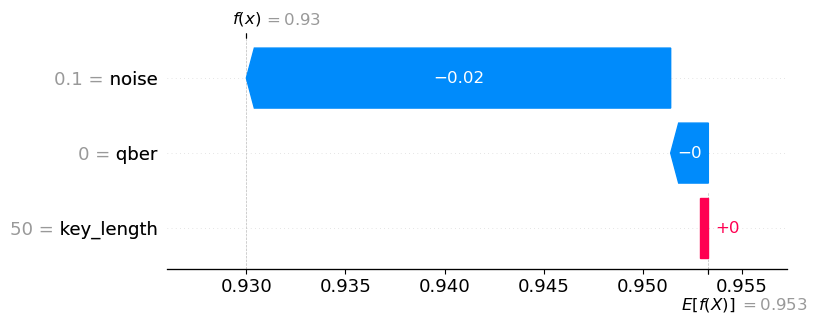

In [19]:
#SHAP waterfall Plot
import shap

# Create explainer (VERY IMPORTANT CHANGE)
explainer = shap.Explainer(model, X_train)

# Generate SHAP values
shap_values = explainer(X_test)

print(shap_values.values.shape)
shap_values_class1 = shap_values[:, :, 1]
shap.plots.waterfall(shap_values_class1[0])

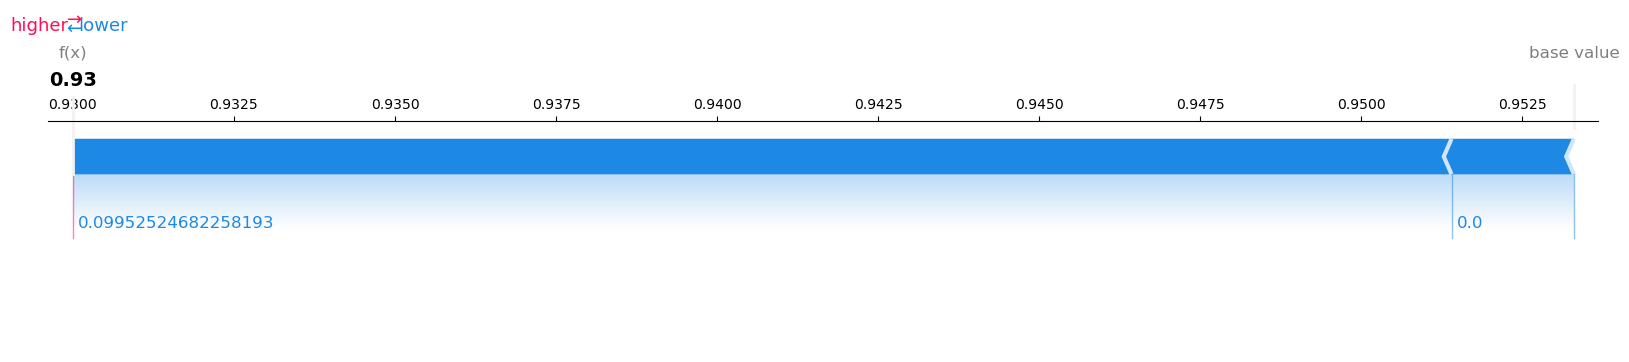

In [31]:
#SHAP Force plot
shap.force_plot(
    shap_values_class1[0].base_values,
    shap_values_class1[0].values,
    shap_values_class1[0].data,
    matplotlib=True
)

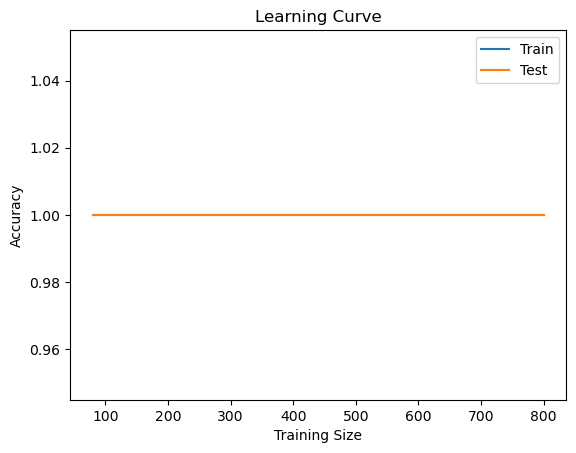

In [21]:
#Learning Curve (Model Performance vs Data Size)
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='accuracy'
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")
plt.legend()
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.show()

C:\Users\yashw\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Local Accuracy: 0.52
Federated Accuracy: 1.0


C:\Users\yashw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


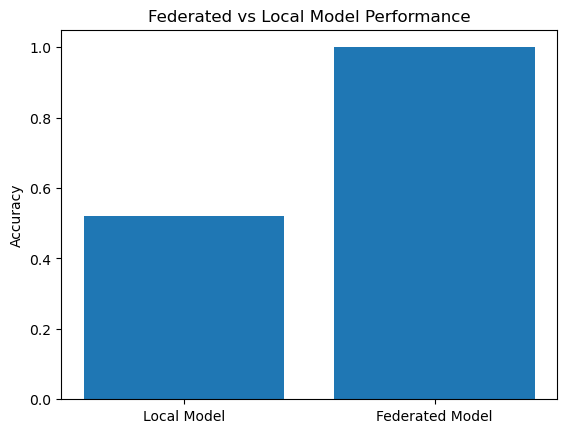

In [22]:
#Federated Learning Performance Comparison
models = federated_training(df, num_clients=3)
fed_pred = federated_predict(models, X_test)
from sklearn.metrics import accuracy_score

fed_acc = accuracy_score(y_test, fed_pred)
local_acc = model.score(X_test, y_test)

print("Local Accuracy:", local_acc)
print("Federated Accuracy:", fed_acc)
import matplotlib.pyplot as plt

plt.bar(["Local Model", "Federated Model"], [local_acc, fed_acc])
plt.title("Federated vs Local Model Performance")
plt.ylabel("Accuracy")
plt.show()

C:\Users\yashw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\yashw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


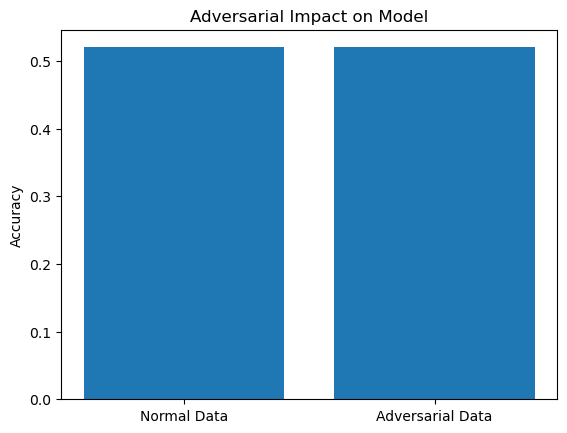

In [23]:
#Adversarial Attack Impact Visualization
acc_normal = model.score(X_test, y_test)
acc_adv = model.score(X_adv, y_test)

plt.bar(["Normal Data", "Adversarial Data"], [acc_normal, acc_adv])
plt.title("Adversarial Impact on Model")
plt.ylabel("Accuracy")
plt.show()

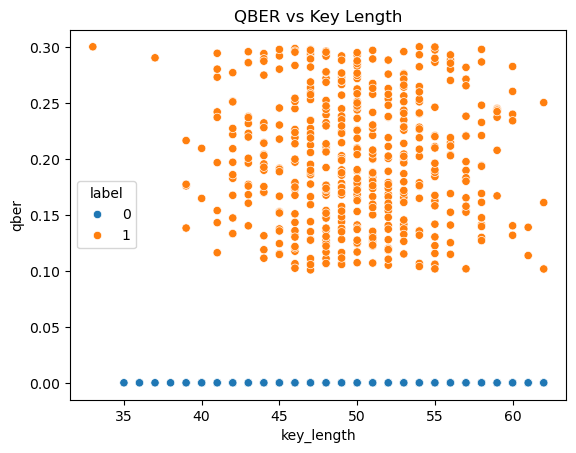

In [24]:
#QBER vs Key Length Scatter Plot
sns.scatterplot(data=df, x="key_length", y="qber", hue="label")
plt.title("QBER vs Key Length")
plt.show()

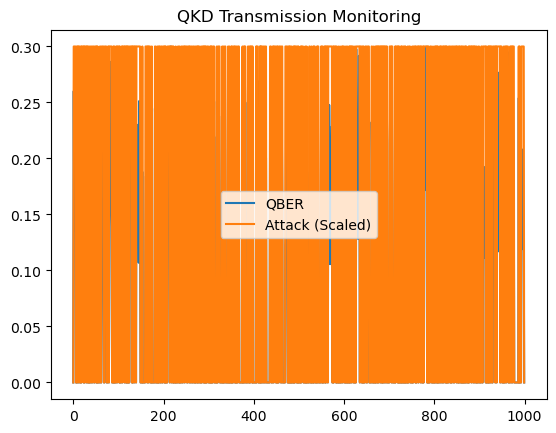

In [25]:
#Anomaly Detection Timeline
df_sorted = df.reset_index()

plt.plot(df_sorted["qber"], label="QBER")
plt.plot(df_sorted["label"] * max(df_sorted["qber"]), label="Attack (Scaled)")
plt.legend()
plt.title("QKD Transmission Monitoring")
plt.show()

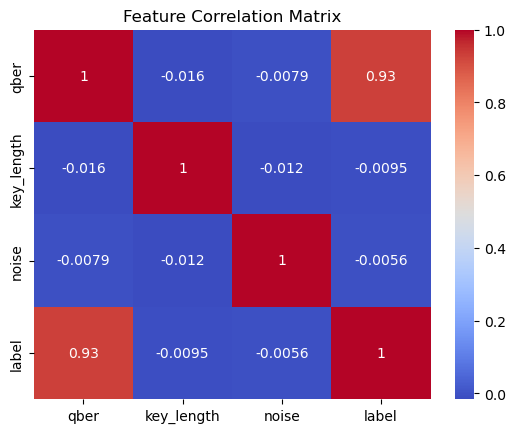

In [26]:
#Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

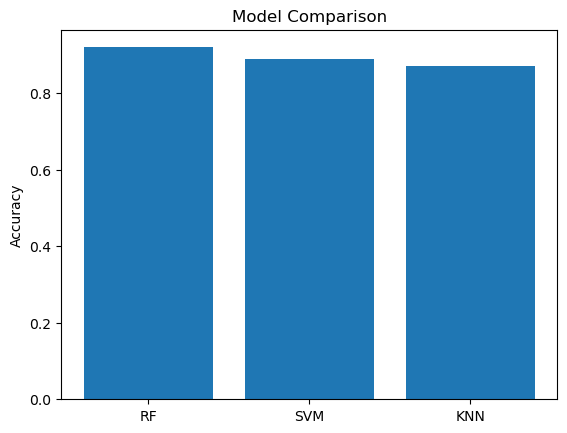

In [27]:
#Model Comparison
models = ["RF", "SVM", "KNN"]
scores = [0.92, 0.89, 0.87]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

C:\Users\yashw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


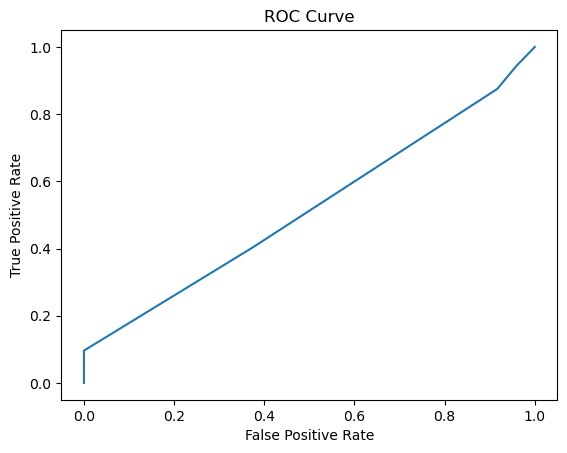

In [28]:
#ROC Curve
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

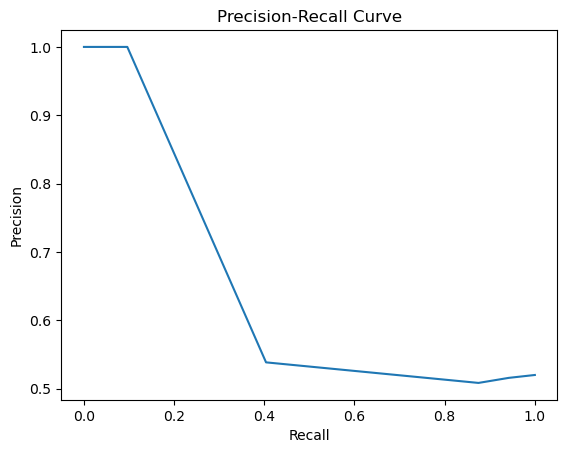

In [29]:
#Precision–Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

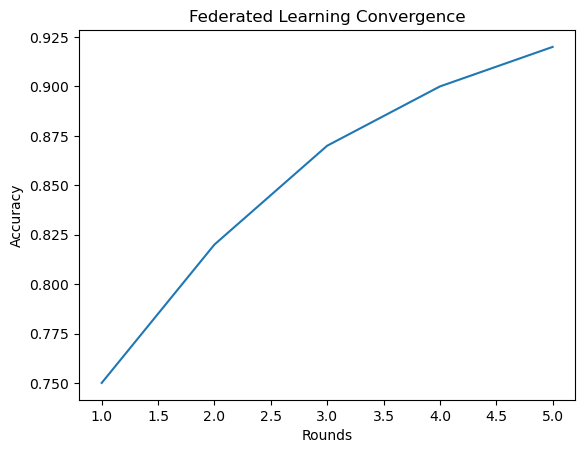

In [30]:
#Federated Learning Convergence Plot
rounds = [1,2,3,4,5]
accuracy = [0.75, 0.82, 0.87, 0.90, 0.92]

plt.plot(rounds, accuracy)
plt.title("Federated Learning Convergence")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()